## Energy Consumption Prediction Model - XGBoost
## FastAPI Compatible | 13 Features

In [1]:
# =========================================================
# 1. IMPORT LIBRARIES
# =========================================================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, cross_val_score
from xgboost import XGBRegressor
from sklearn.metrics import r2_score, mean_squared_error, mean_absolute_error

import warnings
warnings.filterwarnings('ignore')

print(' Libraries imported successfully')

 Libraries imported successfully


In [2]:
# =========================================================
# 2. LOAD DATASET
# =========================================================

data = pd.read_csv('Data/Energy_consumption_data.csv')

print(f'Dataset shape: {data.shape}')
print(f'Columns: {list(data.columns)}')
print('\First 5 rows:')
data.head()

Dataset shape: (8000, 11)
Columns: ['Timestamp', 'Temperature', 'Humidity', 'SquareFootage', 'Occupancy', 'HVACUsage', 'LightingUsage', 'RenewableEnergy', 'DayOfWeek', 'Holiday', 'EnergyConsumption']
\First 5 rows:


,Timestamp,Temperature,Humidity,SquareFootage,Occupancy,HVACUsage,LightingUsage,RenewableEnergy,DayOfWeek,Holiday,EnergyConsumption
0,2022-01-01 00:00:00,22.2973,55.5466,1500.0,2,Off,Off,0.8802,Saturday,No,23.7309
1,2022-01-01 01:00:00,20.3038,52.3797,2500.0,3,Off,On,0.7243,Saturday,No,35.3759
2,2022-01-01 02:00:00,21.0992,54.7912,1200.0,3,On,Off,0.0000,Saturday,No,20.0000
3,2022-01-01 03:00:00,22.0735,61.5958,1000.0,3,On,Off,0.0000,Saturday,No,20.0000
4,2022-01-01 04:00:00,17.8355,67.3722,1800.0,2,On,On,2.3127,Saturday,No,29.9807


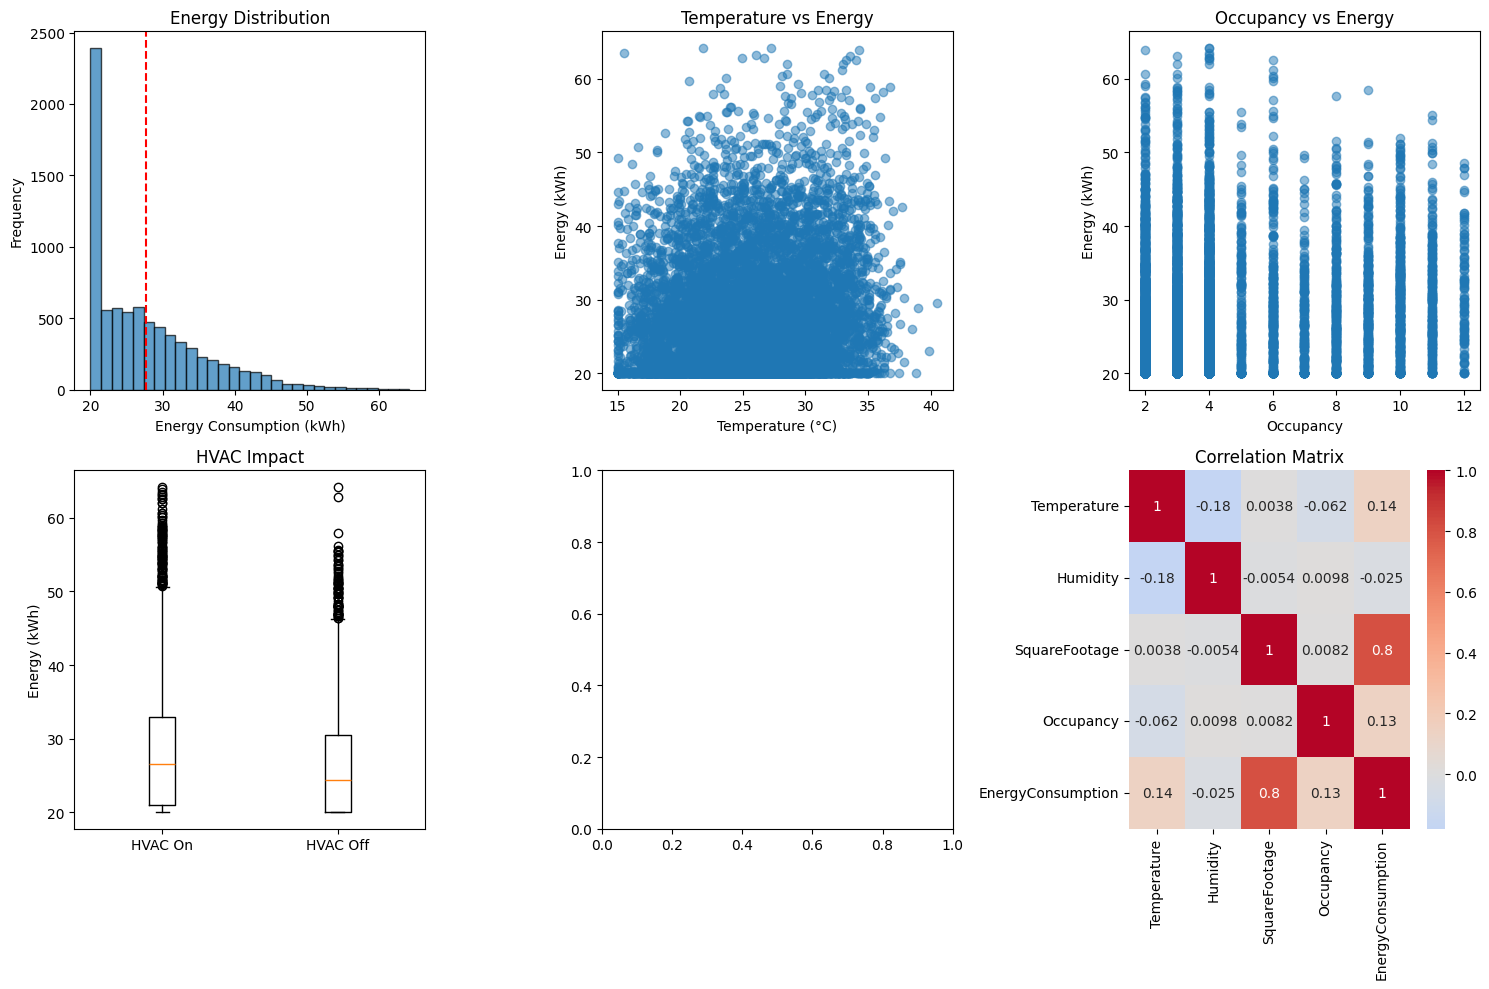

In [3]:
# =========================================================
# 3. EXPLORATORY DATA ANALYSIS
# =========================================================

fig, axes = plt.subplots(2, 3, figsize=(15, 10))

# Energy Distribution
axes[0,0].hist(data['EnergyConsumption'], bins=30, edgecolor='black', alpha=0.7)
axes[0,0].set_xlabel('Energy Consumption (kWh)')
axes[0,0].set_ylabel('Frequency')
axes[0,0].set_title('Energy Distribution')
axes[0,0].axvline(data['EnergyConsumption'].mean(), color='red', linestyle='--')

# Temperature vs Energy
axes[0,1].scatter(data['Temperature'], data['EnergyConsumption'], alpha=0.5)
axes[0,1].set_xlabel('Temperature (°C)')
axes[0,1].set_ylabel('Energy (kWh)')
axes[0,1].set_title('Temperature vs Energy')

# Occupancy vs Energy
axes[0,2].scatter(data['Occupancy'], data['EnergyConsumption'], alpha=0.5)
axes[0,2].set_xlabel('Occupancy')
axes[0,2].set_ylabel('Energy (kWh)')
axes[0,2].set_title('Occupancy vs Energy')

# HVAC Impact
hvac_on = data[data['HVACUsage']=='On']['EnergyConsumption']
hvac_off = data[data['HVACUsage']=='Off']['EnergyConsumption']
axes[1,0].boxplot([hvac_on, hvac_off], labels=['HVAC On', 'HVAC Off'])
axes[1,0].set_ylabel('Energy (kWh)')
axes[1,0].set_title('HVAC Impact')

# Hourly Pattern
if 'Hour' in data.columns:
    hourly_avg = data.groupby('Hour')['EnergyConsumption'].mean()
    axes[1,1].plot(hourly_avg.index, hourly_avg.values, marker='o')
    axes[1,1].set_xlabel('Hour')
    axes[1,1].set_ylabel('Avg Energy')
    axes[1,1].set_title('Hourly Pattern')
    axes[1,1].grid(True, alpha=0.3)

# Correlation Heatmap
numeric_cols = ['Temperature', 'Humidity', 'SquareFootage', 'Occupancy', 'EnergyConsumption']
corr = data[numeric_cols].corr()
sns.heatmap(corr, annot=True, cmap='coolwarm', center=0, ax=axes[1,2])
axes[1,2].set_title('Correlation Matrix')

plt.tight_layout()
plt.show()

In [4]:
# =========================================================
# 4. DATA PREPROCESSING
# =========================================================

# Extract time features
if 'Timestamp' in data.columns:
    data['Timestamp'] = pd.to_datetime(data['Timestamp'])
    data['Hour'] = data['Timestamp'].dt.hour
    data['Day'] = data['Timestamp'].dt.day
    data['Month'] = data['Timestamp'].dt.month

# Convert categorical to numeric
day_mapping = {'Monday':0, 'Tuesday':1, 'Wednesday':2, 'Thursday':3, 
               'Friday':4, 'Saturday':5, 'Sunday':6}
data['DayOfWeek'] = data['DayOfWeek'].map(day_mapping)

data['Holiday'] = data['Holiday'].map({'Yes':1, 'No':0})
data['HVACUsage'] = data['HVACUsage'].map({'On':1, 'Off':0})
data['LightingUsage'] = data['LightingUsage'].map({'On':1, 'Off':0})

# Helper functions
def get_time_period(hour):
    if 5 <= hour < 12: return 0
    elif 12 <= hour < 17: return 1
    elif 17 <= hour < 21: return 2
    else: return 3

def get_weekend_label(day):
    return 1 if day >= 5 else 0

data['WeekendLabel'] = data['DayOfWeek'].apply(get_weekend_label)
data['TimePeriodLabel'] = data['Hour'].apply(get_time_period)

print(' Preprocessing complete')
data.head()

 Preprocessing complete


,Timestamp,Temperature,Humidity,SquareFootage,Occupancy,HVACUsage,LightingUsage,RenewableEnergy,DayOfWeek,Holiday,EnergyConsumption,Hour,Day,Month,WeekendLabel,TimePeriodLabel
0,2022-01-01 00:00:00,22.2973,55.5466,1500.0,2,0,0,0.8802,5,0,23.7309,0,1,1,1,3
1,2022-01-01 01:00:00,20.3038,52.3797,2500.0,3,0,1,0.7243,5,0,35.3759,1,1,1,1,3
2,2022-01-01 02:00:00,21.0992,54.7912,1200.0,3,1,0,0.0000,5,0,20.0000,2,1,1,1,3
3,2022-01-01 03:00:00,22.0735,61.5958,1000.0,3,1,0,0.0000,5,0,20.0000,3,1,1,1,3
4,2022-01-01 04:00:00,17.8355,67.3722,1800.0,2,1,1,2.3127,5,0,29.9807,4,1,1,1,3


In [5]:
# =========================================================
# 5. FEATURES (13 features - FastAPI compatible)
# =========================================================

features = [
    'Temperature', 'Humidity', 'SquareFootage', 'Occupancy',
    'HVACUsage', 'LightingUsage', 'DayOfWeek', 'Holiday',
    'Hour', 'Day', 'Month', 'WeekendLabel', 'TimePeriodLabel'
]

X = data[features]
y = data['EnergyConsumption']

print(f' Using {len(features)} features')
print(f'Features: {features}')

 Using 13 features
Features: ['Temperature', 'Humidity', 'SquareFootage', 'Occupancy', 'HVACUsage', 'LightingUsage', 'DayOfWeek', 'Holiday', 'Hour', 'Day', 'Month', 'WeekendLabel', 'TimePeriodLabel']


In [14]:
# =========================================================
# 6. DATA SCALING
# =========================================================

from sklearn.preprocessing import RobustScaler, StandardScaler

# RobustScaler is better for data with outliers
scaler = RobustScaler()

# Scale the features
X_scaled = scaler.fit_transform(X)
X_scaled = pd.DataFrame(X_scaled, columns=X.columns, index=X.index)
#round to 2 decimal places for better readability
X_scaled = X_scaled.round(2)
X_scaled.to_csv('Data/X_scaled.csv', index=False)

print('Data scaled using RobustScaler')
print(f'Scaled data shape: {X_scaled.shape}')


Data scaled using RobustScaler
Scaled data shape: (8000, 13)


Training samples: 6400
Testing samples: 1600


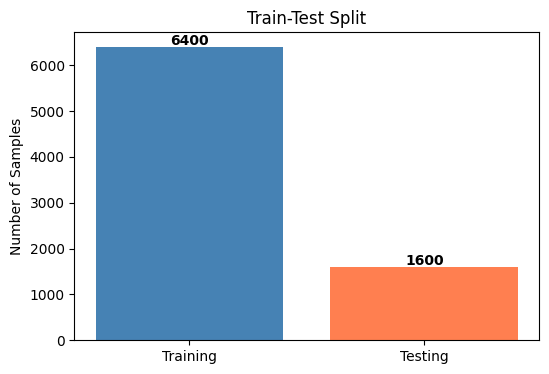

In [7]:
# =========================================================
# 6. TRAIN-TEST SPLIT
# =========================================================

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

print(f'Training samples: {len(X_train)}')
print(f'Testing samples: {len(X_test)}')

# Visualize split
plt.figure(figsize=(6, 4))
plt.bar(['Training', 'Testing'], [len(X_train), len(X_test)], color=['steelblue', 'coral'])
plt.ylabel('Number of Samples')
plt.title('Train-Test Split')
for i, v in enumerate([len(X_train), len(X_test)]):
    plt.text(i, v + 50, str(v), ha='center', fontweight='bold')
plt.show()

In [8]:
# =========================================================
# 7. TRAIN XGBOOST MODEL
# =========================================================

print(' Training XGBoost model...')

model = XGBRegressor(
    n_estimators=500,
    max_depth=7,
    learning_rate=0.05,
    subsample=0.8,
    colsample_bytree=0.8,
    reg_alpha=0.1,
    reg_lambda=1.0,
    random_state=42,
    n_jobs=-1
)

model.fit(X_train, y_train)
print(' Model training complete!')

 Training XGBoost model...
 Model training complete!


In [9]:
# =========================================================
# 8. MODEL EVALUATION
# =========================================================

y_pred = model.predict(X_test)

r2 = r2_score(y_test, y_pred)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))
mae = mean_absolute_error(y_test, y_pred)
mape = np.mean(np.abs((y_test - y_pred) / y_test)) * 100

print('='*60)
print('MODEL PERFORMANCE')
print('='*60)
print(f'R² Score  : {r2:.4f} {" (85%+ Achieved!)" if r2 >= 0.85 else " Below target"}')
print(f'RMSE      : {rmse:.2f} kWh')
print(f'MAE       : {mae:.2f} kWh')
print(f'MAPE      : {mape:.2f}%')
print('='*60)

MODEL PERFORMANCE
R² Score  : 0.8805  (85%+ Achieved!)
RMSE      : 2.67 kWh
MAE       : 2.00 kWh
MAPE      : 7.34%


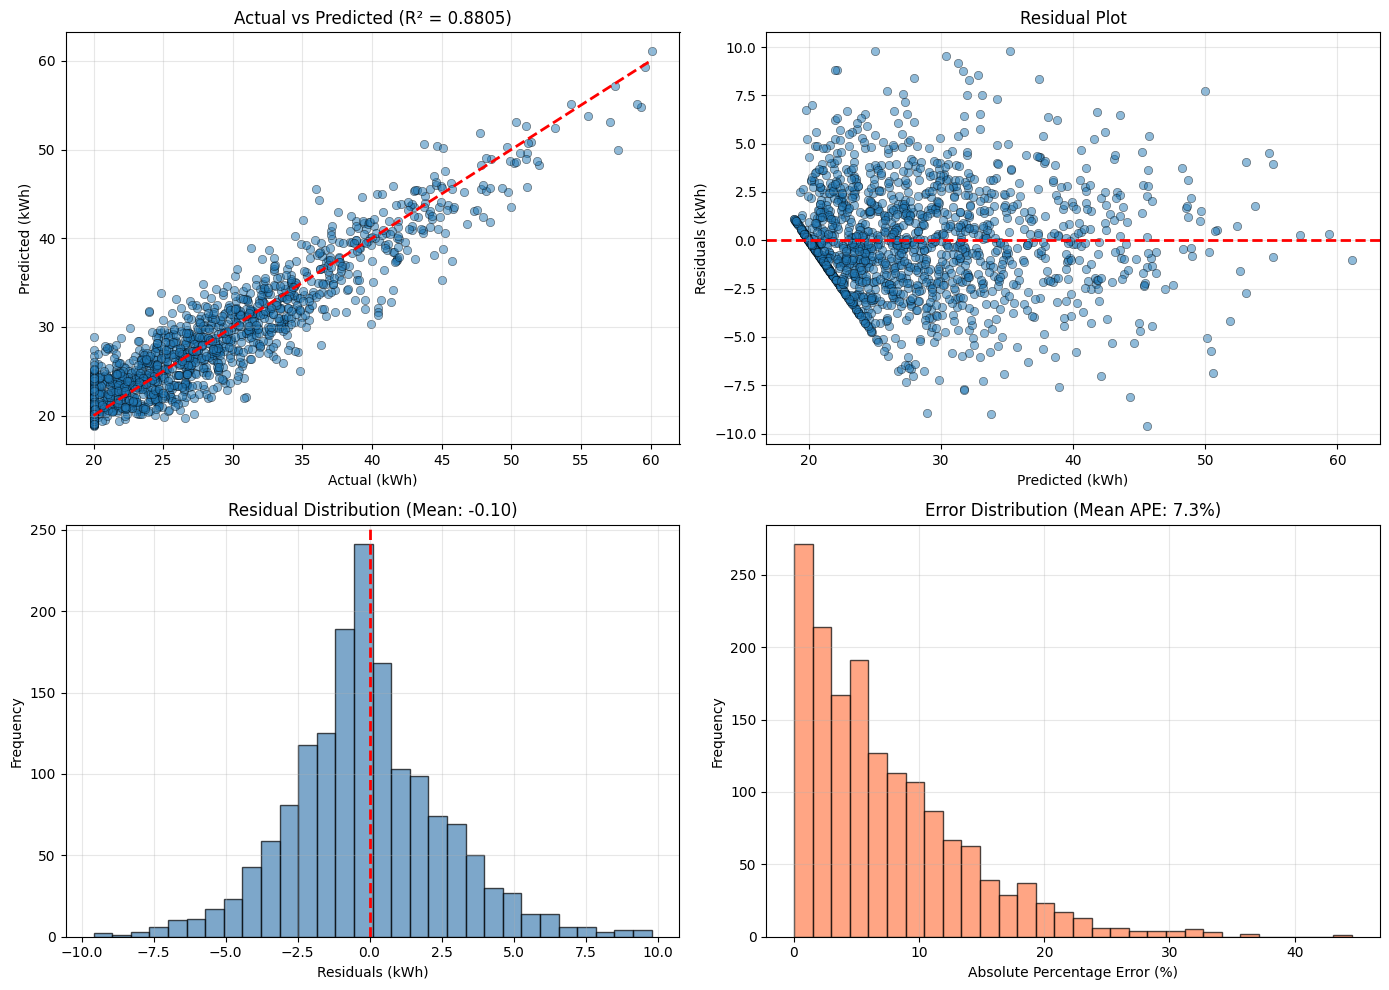

In [10]:
# =========================================================
# 9. VISUALIZATIONS
# =========================================================

fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# Actual vs Predicted
axes[0,0].scatter(y_test, y_pred, alpha=0.5, edgecolors='k', linewidth=0.5)
axes[0,0].plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--', lw=2)
axes[0,0].set_xlabel('Actual (kWh)')
axes[0,0].set_ylabel('Predicted (kWh)')
axes[0,0].set_title(f'Actual vs Predicted (R² = {r2:.4f})')
axes[0,0].grid(True, alpha=0.3)

# Residuals
residuals = y_test - y_pred
axes[0,1].scatter(y_pred, residuals, alpha=0.5, edgecolors='k', linewidth=0.5)
axes[0,1].axhline(y=0, color='r', linestyle='--', lw=2)
axes[0,1].set_xlabel('Predicted (kWh)')
axes[0,1].set_ylabel('Residuals (kWh)')
axes[0,1].set_title('Residual Plot')
axes[0,1].grid(True, alpha=0.3)

# Residual Distribution
axes[1,0].hist(residuals, bins=30, edgecolor='black', alpha=0.7, color='steelblue')
axes[1,0].axvline(x=0, color='r', linestyle='--', lw=2)
axes[1,0].set_xlabel('Residuals (kWh)')
axes[1,0].set_ylabel('Frequency')
axes[1,0].set_title(f'Residual Distribution (Mean: {residuals.mean():.2f})')
axes[1,0].grid(True, alpha=0.3)

# Prediction Error %
error_pct = np.abs((y_test - y_pred) / y_test) * 100
axes[1,1].hist(error_pct, bins=30, edgecolor='black', alpha=0.7, color='coral')
axes[1,1].set_xlabel('Absolute Percentage Error (%)')
axes[1,1].set_ylabel('Frequency')
axes[1,1].set_title(f'Error Distribution (Mean APE: {mape:.1f}%)')
axes[1,1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

FEATURE IMPORTANCE RANKING
 3. SquareFootage        : 0.5564 ███████████████████████████
 6. LightingUsage        : 0.1039 █████
 9. Hour                 : 0.0949 ████
13. TimePeriodLabel      : 0.0840 ████
 4. Occupancy            : 0.0424 ██
12. WeekendLabel         : 0.0323 █
 7. DayOfWeek            : 0.0167 
 5. HVACUsage            : 0.0158 
 2. Humidity             : 0.0114 
11. Month                : 0.0111 
 1. Temperature          : 0.0107 
 8. Holiday              : 0.0104 
10. Day                  : 0.0102 


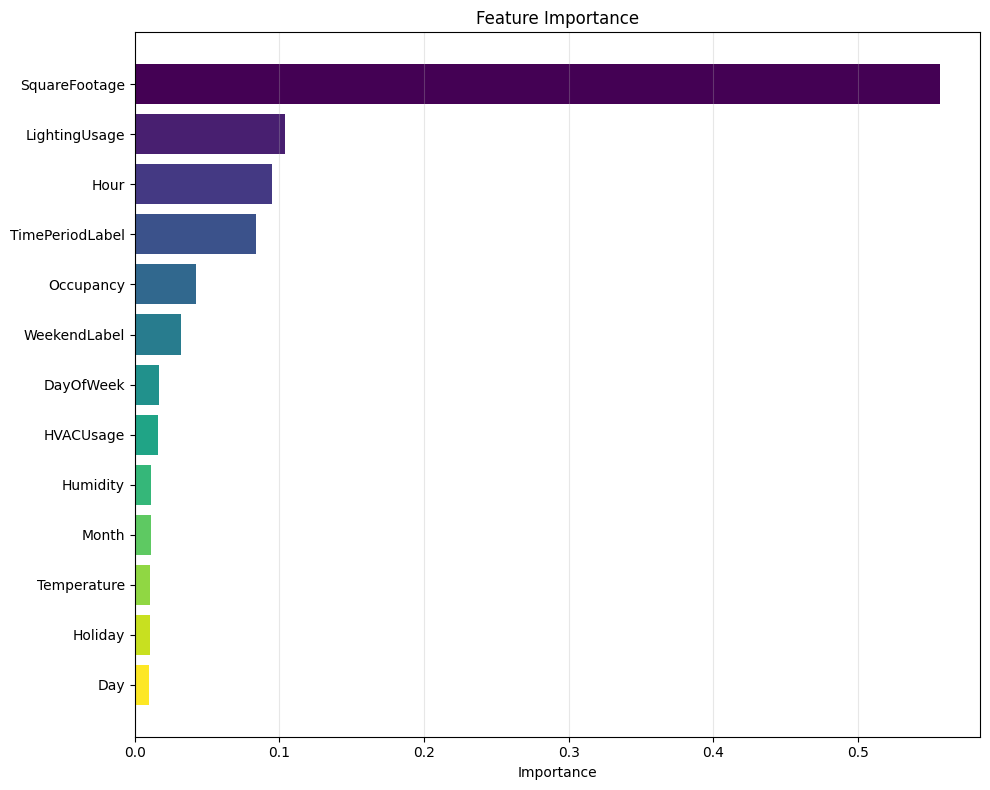

In [11]:
# =========================================================
# 10. FEATURE IMPORTANCE
# =========================================================

importance_df = pd.DataFrame({
    'Feature': features,
    'Importance': model.feature_importances_
}).sort_values('Importance', ascending=False)


print('FEATURE IMPORTANCE RANKING')
print('='*60)
for i, row in importance_df.iterrows():
    bar = '█' * int(row['Importance'] * 50)
    print(f'{i+1:2}. {row["Feature"]:20} : {row["Importance"]:.4f} {bar}')

# Visualization
plt.figure(figsize=(10, 8))
colors = plt.cm.viridis(np.linspace(0, 1, len(importance_df)))
plt.barh(range(len(importance_df)), importance_df['Importance'].values, color=colors)
plt.yticks(range(len(importance_df)), importance_df['Feature'].values)
plt.xlabel('Importance')
plt.title('Feature Importance')
plt.gca().invert_yaxis()
plt.grid(True, alpha=0.3, axis='x')
plt.tight_layout()
plt.show()

5-FOLD CROSS VALIDATION
Fold 1: R² = 0.8823
Fold 2: R² = 0.8854
Fold 3: R² = 0.8850
Fold 4: R² = 0.8764
Fold 5: R² = 0.8683
\Mean R²: 0.8795
Std Dev: 0.0064


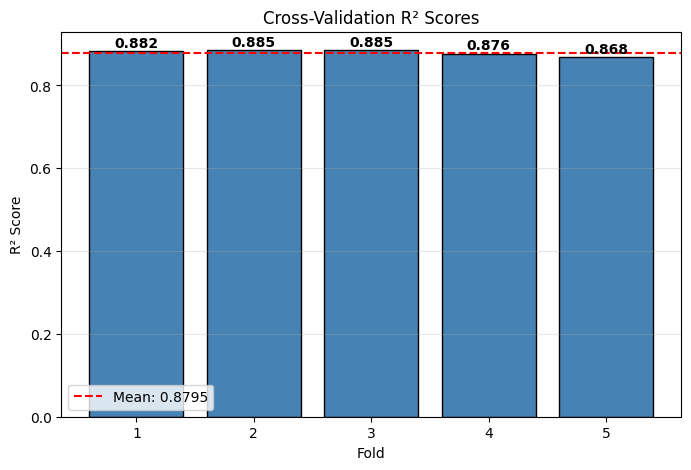

In [12]:
# =========================================================
# 11. CROSS VALIDATION
# =========================================================

cv_scores = cross_val_score(model, X, y, cv=5, scoring='r2')

print('5-FOLD CROSS VALIDATION')
print('='*60)
for i, score in enumerate(cv_scores, 1):
    print(f'Fold {i}: R² = {score:.4f}')
print(f'\Mean R²: {cv_scores.mean():.4f}')
print(f'Std Dev: {cv_scores.std():.4f}')

# Visualization
plt.figure(figsize=(8, 5))
plt.bar(range(1, 6), cv_scores, color='steelblue', edgecolor='black')
plt.axhline(y=cv_scores.mean(), color='red', linestyle='--', label=f'Mean: {cv_scores.mean():.4f}')
plt.xlabel('Fold')
plt.ylabel('R² Score')
plt.title('Cross-Validation R² Scores')
plt.legend()
plt.grid(True, alpha=0.3, axis='y')
for i, v in enumerate(cv_scores, 1):
    plt.text(i, v + 0.01, f'{v:.3f}', ha='center', fontweight='bold')
plt.show()

In [13]:
# =========================================================
# 12. SAMPLE PREDICTIONS
# =========================================================

test_scenarios = [
    ['Small Home - Night', [22, 45, 300, 2, 0, 0, 2, 0, 3, 15, 1, 0, 3]],
    ['Medium Home - Afternoon', [35, 65, 750, 4, 1, 1, 2, 0, 14, 15, 7, 0, 1]],
    ['Large Commercial - Peak', [32, 60, 1000, 15, 1, 1, 3, 0, 18, 15, 7, 0, 2]]
]


print('SAMPLE PREDICTIONS')
print('='*60)

for name, input_data in test_scenarios:
    input_df = pd.DataFrame([input_data], columns=features)
    pred = model.predict(input_df)[0]
    print(f'{name:25} : {pred:.2f} kWh')

SAMPLE PREDICTIONS
Small Home - Night        : 19.57 kWh
Medium Home - Afternoon   : 21.28 kWh
Large Commercial - Peak   : 30.01 kWh
